# Technical Project - Subjective Classification

## Model 1 - MLP

## Preprocessing


Loads dataset CSV splits and extracts unigram TF-IDF features while keeping `?` and `!` marks as subjectivity tokens. Vocabulary is fitted only on training data, transforming all splits into dense feature arrays alongside reshaped binary label vectors.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import csv

def load_text(filepath):
    texts, labels = [], []
    with open(filepath, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            texts.append(row['text'])
            labels.append(int(row['label']))
    return texts, labels

train_texts, train_labels = load_text('train_data.csv')
val_texts, val_labels = load_text('val_data.csv')
test_texts, test_labels = load_text('test_data.csv')

print("Train size:", len(train_texts), "Validation size:", len(val_texts), "Test size:", len(test_texts)) #sanity check



vectorizer = TfidfVectorizer(ngram_range=(1, 1), token_pattern=r"(?u)\b\w+\b|[!?]{1,}", min_df=2) 
''' include ? and ! as tokens as they should be relevant for subjectivity. Start with unigrams only for now. Will test bi and trigrams later. '''

x_train = vectorizer.fit_transform(train_texts).toarray().astype('float32')
x_val   = vectorizer.transform(val_texts).toarray().astype('float32')
x_test  = vectorizer.transform(test_texts).toarray().astype('float32')

import numpy as np
y_train = np.array(train_labels, dtype='float32').reshape(-1, 1)
y_val   = np.array(val_labels,   dtype='float32').reshape(-1, 1)
y_test  = np.array(test_labels,  dtype='float32').reshape(-1, 1)

input_size = x_train.shape[1]
print(x_train.shape, y_train.shape, input_size)



Train size: 6400 Validation size: 1600 Test size: 2000
(6400, 8552) (6400, 1) 8552


## Build the MLP

A single hidden layer network using ReLU and Sigmoid output for binary classification. Forward passes compute predictions, while backpropagation calculates cross-entropy gradients with L2 regularization to update weights. The training loop shuffles mini-batches each epoch and tracks metrics to monitor overfitting.

In [ ]:
#build the mlp

import numpy as np
import random



class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01  #change the inital weight activation if problems in training
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

    def forward_pass(self, text):
        self.text = text  # store for backprop
        z1 = np.dot(text, self.weights_input_hidden) + self.bias_hidden
        self.a1 = self.ReLu(z1)
        z2 = np.dot(self.a1, self.weights_hidden_output) + self.bias_output
        output = self.sigmoid(z2)
        return output, self.a1 
    
    def ReLu(self, x):
        return np.maximum(0, x)
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def compute_loss(self, output, target, l2_lambda=0.01):
        eps=1e-15 
        loss = -np.mean(target * np.log(output + eps) + (1 - target) * np.log(1 - output + eps))

        return loss

    def backward_pass(self, output, target, l2_lambda=0.01):
        dz2 = output - target
        dw2 = np.dot(self.a1.T, dz2) / target.shape[0] + 2 * l2_lambda * self.weights_hidden_output  # Add L2 regularization term
        db2 = np.sum(dz2, axis=0, keepdims=True) / target.shape[0]
        dz1 = np.dot(dz2, self.weights_hidden_output.T) * (self.a1 > 0)
        dw1 = np.dot(self.text.T, dz1) / target.shape[0] + 2 * l2_lambda * self.weights_input_hidden  # Add L2 regularization term
        db1 = np.sum(dz1, axis=0, keepdims=True) / target.shape[0]
        return dw1, db1, dw2, db2

        

    def update_weights(self, dw1, db1, dw2, db2, learning_rate):
        self.weights_input_hidden -= learning_rate * dw1
        self.bias_hidden -= learning_rate * db1
        self.weights_hidden_output -= learning_rate * dw2
        self.bias_output -= learning_rate * db2

    def train(self, x_train, y_train, x_val, y_val, epochs=1000, learning_rate=0.01, l2_lambda=0.01):
        print("Epochs:", epochs)
        history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
        for epoch in range(epochs):
            mini_batches = create_mini_batches(x_train, y_train, batch_size=32)
            epoch_loss = 0
            for x_batch, y_batch in mini_batches:
                output, _ = self.forward_pass(x_batch)
                loss = self.compute_loss(output, y_batch, l2_lambda)
                dw1, db1, dw2, db2 = self.backward_pass(output, y_batch, l2_lambda)
                self.update_weights(dw1, db1, dw2, db2, learning_rate)
                epoch_loss += loss
   
            average_train_loss = epoch_loss / len(mini_batches)
            train_output, _ = self.forward_pass(x_train)
            train_accuracy = np.mean((train_output > 0.5) == y_train)

            val_output, _ = self.forward_pass(x_val)
            val_loss = self.compute_loss(val_output, y_val, l2_lambda)
            val_accuracy = np.mean((val_output > 0.5) == y_val)
            
            history['train_accuracy'].append(train_accuracy)
            history['val_accuracy'].append(val_accuracy)
            history['train_loss'].append(average_train_loss)
            history['val_loss'].append(val_loss)
        
            if epoch % 100 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}, Train Loss: {average_train_loss}, Val Loss: {val_loss}")
            
            if epoch == epochs - 1:
                best_epoch_loss = np.argmin(history['val_loss'])    #find best epoch as 1000 epochs seemed redundant and showed overfitting
                print(f"Best epoch: {best_epoch_loss}, Best Val Loss: {history['val_loss'][best_epoch_loss]}, Train Accuracy: {history['train_accuracy'][best_epoch_loss]}, Val Accuracy: {history['val_accuracy'][best_epoch_loss]}")

        return history
    
    def create_mini_batches(x_train, y_train, batch_size):
    indices = np.arange(x_train.shape[0])
    np.random.shuffle(indices)
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices] #shuffle data preserving labels pairing
    
    mini_batches = []
    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train_shuffled[i:i + batch_size]
        y_batch = y_train_shuffled[i:i + batch_size]
        mini_batches.append((x_batch, y_batch))
    
    return mini_batches    

## Create plots for visualisation

In [ ]:
import matplotlib.pyplot as plt

def train_loss_plot(history):
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('mlp_baseline_overfitting_curve.png', dpi=150, bbox_inches='tight')
    plt.show()


## Training

In [ ]:
model = SimpleMLP(input_size=x_train.shape[1], hidden_size=8, output_size=1)
history = model.train(x_train, y_train, x_val, y_val, epochs=1000, learning_rate=0.01, l2_lambda=0)



Epochs: 1000
Epoch 0, Train Loss: 0.693174224180121, Val Loss: 0.6931468776387933
Epoch 100, Train Loss: 0.6543379345159696, Val Loss: 0.6522698350964814
Epoch 200, Train Loss: 0.20691941499734154, Val Loss: 0.27053907376186354
Epoch 300, Train Loss: 0.09813643469341066, Val Loss: 0.24589042841975664
Epoch 400, Train Loss: 0.05275217243670607, Val Loss: 0.2551436211718635
Epoch 500, Train Loss: 0.03205616814762453, Val Loss: 0.27058171084481647
Epoch 600, Train Loss: 0.02161820755983904, Val Loss: 0.2850272041020038
Epoch 700, Train Loss: 0.015703676250927116, Val Loss: 0.2979372152980309
Epoch 800, Train Loss: 0.012079030331096243, Val Loss: 0.30961725742669044
Epoch 900, Train Loss: 0.009660003836398085, Val Loss: 0.31936663066076393
Epoch 999, Train Loss: 0.007984954270412431, Val Loss: 0.3283854392066934
Best epoch: 298, Best Val Loss: 0.24583593736906878, Train Accuracy: 0.9821875, Val Accuracy: 0.898125


## Model 2 - Attention

## Preprocessing

It was necessary to change preprocessing from the last model as the TF-IDF Vectorizer does not preserve word order. Instead we used sequential padding to keep all the lines uniform and enable the self-attention mechanism to attend to word order.

In [ ]:
''' preserve word order, keep ! and ? as tokens, and use a minimum document frequency of 2 for the vocabulary'''

import re
from collections import Counter
import numpy as np
import csv

def load_text(filepath):
    texts, labels = [], []
    with open(filepath, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            texts.append(row['text'])
            labels.append(int(row['label']))
    return texts, labels

train_texts, train_labels = load_text('train_data.csv')
val_texts, val_labels = load_text('val_data.csv')
test_texts, test_labels = load_text('test_data.csv')


token_pattern = re.compile(r"[\w!?]+") #keep the ! and ? just like before

def tokenize(text):
    return token_pattern.findall(text)

def build_vocab(texts, min_df=2):
    token_counts = Counter()
    for text in texts:
        tokens = tokenize(text)
        token_counts.update(tokens)
    return {token for token, count in token_counts.items() if count >= min_df}  #return tokens that appear at least min_df times matching other model

vocab = build_vocab(train_texts, min_df=2)  

word2idx = {'<PAD>': 0, '<UNK>': 1}  # reserve index 0 for padding and 1 for unknown tokens
start_idx = 2
for word in vocab:
    word2idx[word] = start_idx
    start_idx += 1              #assign index to each word in vocab starting with 2





def tokens_index(tokens, word2idx):
    return [word2idx.get(token, word2idx['<UNK>']) for token in tokens]  #look up the index of each token in word2idx, if not found return index of <UNK>


train_tokenized = [tokens_index(tokenize(text), word2idx) for text in train_texts]
val_tokenized = [tokens_index(tokenize(text), word2idx) for text in val_texts]
test_tokenized = [tokens_index(tokenize(text), word2idx) for text in test_texts]

maxlen = max(len(tokens) for tokens in train_tokenized)  #find the maximum length of tokens in training data, are similar lengths already 

def pad_sequence(ids, maxlen, pad_id=0):
    if len(ids) >= maxlen:
        return ids[:maxlen]
    return ids + [pad_id] * (maxlen - len(ids))

train_padded = np.array([pad_sequence(ids, maxlen) for ids in train_tokenized])
train_mask = (train_padded !=0).astype(int) #create an array indicating 1 for real token vs padding 0 will use later


val_padded = np.array([pad_sequence(ids, maxlen) for ids in val_tokenized])
val_mask = (val_padded != 0).astype(int)

#reshape for training
y_train = np.array(train_labels).reshape(-1, 1)
y_val = np.array(val_labels).reshape(-1, 1)


vocab_size = len(word2idx)  




## Building the Model

Instead of using one-hot vectors or TF-IDF, the model learns a 50-dimensional vector representation for every word. We initialize the embedding matrix with small random numbers scaled using Xavier initalization to address the vanishing gradient problem. During each forward pass, the model looks up the corresponding 50-D vector for each token ID in the sequence.

In [ ]:


def init_embeddings(vocab_size, embedding_dim=50):
    scale = np.sqrt(1.0 / embedding_dim)  #inital size was too small
    embedding_matrix = np.random.randn(vocab_size, embedding_dim) * scale
    return embedding_matrix

def embedding_forward(token_ids, embedding_matrix):
    embedded = embedding_matrix[token_ids] #match the token ids to our embedding matrix
    return embedded

def embedding_backward(d_embedded, token_ids, vocab_size, embedding_dim):  
    d_embedding_matrix = np.zeros((vocab_size, embedding_dim)) 
    np.add.at(d_embedding_matrix, token_ids, d_embedded) #allows us to process multiple identical ids in the same document wihtout overwriting
    return d_embedding_matrix


In [ ]:
def init_weights(d_k, embedding_dim=50):
   # using as initial setting wouldn't work
    scale = np.sqrt(1.0 / embedding_dim)

    wq = np.random.randn(embedding_dim, d_k) * scale
    wk = np.random.randn(embedding_dim, d_k) * scale
    wv = np.random.randn(embedding_dim, d_k) * scale
    return wq, wk, wv

def softmax(x, axis=-1):
    x_stable = x - np.max(x, axis=axis, keepdims=True) #for numerical stability precent overflow
    exp_x = np.exp(x_stable)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def forward_pass_att(embedded, mask, wq, wk, wv, d_k):
    Q, K, V = embedded @ wq, embedded @ wk, embedded @ wv
    scores = (Q @ K.transpose(0, 2, 1)) / np.sqrt(d_k)
    
    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True)) # softmax across sequence dimension
    attn_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)

    attention_output = (attn_weights @ V) * mask[:, :, None]
    
    return attention_output, attn_weights, Q, K, V






Zeros out padding tokens using a binary mask, then averages only valid word vectors to produce a single summary vector per document. During backprop, incoming gradients are distributed evenly across valid token positions while sending zero gradient to padded tokens.


Unrolls attention scores back into Query, Key, and Value gradients by accounting for how attention weights interact across valid sequence positions. Then averages batch gradients to update projection matrices and combines all three projection paths to send gradients back to the input embeddings.

In [ ]:


def masked_pool(attention_output, mask):
    # zero out pad tokens
    mask_expanded = mask[:, :, None]
    masked_output = attention_output * mask_expanded
    
    # average across valid tokens
    summed_output = masked_output.sum(axis=1)
    counts = mask.sum(axis=1, keepdims=True)
    pooled = summed_output / counts

    return pooled, counts


def back_pool(d_pool, mask, counts):
    d_sum = d_pool / counts
    d_masked = d_sum[:, None, :]
    d_attention_output = d_masked * mask[:, :, None]

    return d_attention_output

def attention_backward(d_attn_out, Q, K, V, attn_weights, mask, emb, wq, wk, wv, d_k):
    batch_size = emb.shape[0] 
    
    
    d_V = attn_weights.transpose(0, 2, 1) @ d_attn_out
    d_attn_weights = d_attn_out @ V.transpose(0, 2, 1)
    
    
    sum_d_attn = np.sum(d_attn_weights * attn_weights, axis=-1, keepdims=True)
    d_scores = attn_weights * (d_attn_weights - sum_d_attn)
    d_scores = d_scores / np.sqrt(d_k)
    
 
    d_Q = d_scores @ K
    d_K = d_scores.transpose(0, 2, 1) @ Q
    

    d_wq = np.sum(emb.transpose(0, 2, 1) @ d_Q, axis=0) / batch_size
    d_wk = np.sum(emb.transpose(0, 2, 1) @ d_K, axis=0) / batch_size
    d_wv = np.sum(emb.transpose(0, 2, 1) @ d_V, axis=0) / batch_size
    
    
    d_emb = (d_Q @ wq.T) + (d_K @ wk.T) + (d_V @ wv.T)
    
    return d_emb, d_wq, d_wk, d_wv





Model pipeling = Runs token embeddings, self-attention, pooling, and a Sigmoid linear layer end-to-end to output predictions. Backprop then flows in reverse—from output down through pooling and attention back to update the embedding matrix.

Loss & Weight updates = Calculates binary cross-entropy loss with clipped predictions and updates parameters via gradient descent using weight decay (skipping biases). Mini-batches are shuffled every epoch for stable training.

In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

# simple wrapper to run forward pass end-to-end
def forward_pass(token_ids, mask, embedding_matrix, wq, wk, wv, d_k, w_out, b_out):
    emb = embedding_forward(token_ids, embedding_matrix)
    attn_out, attn_weights, Q, K, V = forward_pass_att(emb, mask, wq, wk, wv, d_k) 
                                               
    pooled, counts = masked_pool(attn_out, mask) # pool seq vectors and project to output score
    logits = pooled @ w_out + b_out
    preds = sigmoid(logits)
    
    
    cache = (token_ids, emb, Q, K, V, attn_weights, mask, counts, pooled, preds, d_k)  # save for backward
    return preds, cache


def backward_pass(d_loss, cache, embedding_matrix, wq, wk, wv, w_out):
    token_ids, emb, Q, K, V, attn_weights, mask, counts, pooled, preds, d_k = cache
    batch_size = token_ids.shape[0]
    
    # Average logit gradient over mini-batch
    d_logits = d_loss / batch_size
    
    d_w_out = pooled.T @ d_logits
    d_b_out = np.sum(d_logits, axis=0, keepdims=True)
    d_pooled = d_logits @ w_out.T
    
    # pool to attention, attention to embeddings
    d_attn_out = back_pool(d_pooled, mask, counts)
    d_emb, d_wq, d_wk, d_wv = attention_backward(d_attn_out, Q, K, V, attn_weights, mask, emb, wq, wk, wv, d_k)
    
    v_size, e_dim = embedding_matrix.shape
    d_emb_matrix = embedding_backward(d_emb, token_ids, v_size, e_dim)
    
    grads = {
        'embedding_matrix': d_emb_matrix,
        'wq': d_wq,
        'wk': d_wk,
        'wv': d_wv,
        'w_out': d_w_out,
        'b_out': d_b_out
    }
    return grads

def update_weights(params, grads, lr=0.1, weight_decay=1e-4): #add weight decay to stop overfitting
    for k in params:
        if k == 'b_out':    #skip biases
            params[k] -= lr * grads[k]
        else:
            
            grad_with_decay = grads[k] + weight_decay * params[k]
            params[k] -= lr * grad_with_decay
            
    return params

def compute_bce_loss(preds, targets):
    eps = 1e-15
    preds_clipped = np.clip(preds, eps, 1 - eps)
    loss = -np.mean(targets * np.log(preds_clipped) + (1 - targets) * np.log(1 - preds_clipped))
    return loss

def compute_bce_grad(preds, targets):
     return preds - targets 

def create_mini_batches(X, mask, y, batch_size=32, shuffle=True):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)
        
    for start_idx in range(0, n_samples, batch_size):
        batch_idx = indices[start_idx : start_idx + batch_size]
        # reshape y to avoid bugs
        yield X[batch_idx], mask[batch_idx], y[batch_idx].reshape(-1, 1)

## Training


Initializes all parameters into a state dictionary using scaled random weights for embeddings, attention projections, and the output layer. Training loops over mini-batches per epoch to run forward passes, loss calculations, backprop, and weight updates. Tracks train/validation loss and accuracy every epoch, stopping early if validation loss stops improving.

In [ ]:
class SimpleAttentionClassifier:
    def __init__(self, vocab_size, embedding_dim, d_k):
        embedding_matrix = init_embeddings(vocab_size, embedding_dim)
        wq, wk, wv = init_weights(d_k, embedding_dim=embedding_dim)
        w_out = np.random.randn(embedding_dim, 1) * 0.01
        b_out = np.zeros((1, 1))
        self.params = {
            'embedding_matrix': embedding_matrix,
            'wq': wq, 'wk': wk, 'wv': wv,
            'w_out': w_out, 'b_out': b_out
        }
        self.d_k = d_k
    
    def train(self, x_train, mask_train, y_train, x_val, mask_val, y_val, epochs=100, learning_rate=0.01, weight_decay=1e-4, patience=15):
        print("Epochs:", epochs)
        history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
        
        best_val_loss = np.inf
        epochs_without_improvement = 0
        
        for epoch in range(epochs):
            mini_batches = create_mini_batches(x_train, mask_train, y_train, batch_size=32)
            epoch_loss = 0
            n_batches = 0
            for x_batch, mask_batch, y_batch in mini_batches:
                output, cache = forward_pass(
                    x_batch, mask_batch,
                    self.params['embedding_matrix'], self.params['wq'], self.params['wk'], self.params['wv'],
                    self.d_k, self.params['w_out'], self.params['b_out']
                )
                loss = compute_bce_loss(output, y_batch)
                d_loss = compute_bce_grad(output, y_batch)
                grads = backward_pass(
                    d_loss, cache,
                    self.params['embedding_matrix'], self.params['wq'], self.params['wk'], self.params['wv'],
                    self.params['w_out']
                )
                self.params = update_weights_with_l2(self.params, grads, lr=learning_rate, weight_decay=weight_decay)
                epoch_loss += loss
                n_batches += 1

            average_train_loss = epoch_loss / n_batches
            train_output, _ = forward_pass(
                x_train, mask_train,
                self.params['embedding_matrix'], self.params['wq'], self.params['wk'], self.params['wv'],
                self.d_k, self.params['w_out'], self.params['b_out']
            )
            train_accuracy = np.mean((train_output > 0.5) == y_train)

            val_output, _ = forward_pass(
                x_val, mask_val,
                self.params['embedding_matrix'], self.params['wq'], self.params['wk'], self.params['wv'],
                self.d_k, self.params['w_out'], self.params['b_out']
            )
            val_loss = compute_bce_loss(val_output, y_val)
            val_accuracy = np.mean((val_output > 0.5) == y_val)

            history['train_accuracy'].append(train_accuracy)
            history['val_accuracy'].append(val_accuracy)
            history['train_loss'].append(average_train_loss)
            history['val_loss'].append(val_loss)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}, Train Loss: {average_train_loss:.4f}, Val Loss: {val_loss:.4f}")

            # early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                    break

        best_epoch = np.argmin(history['val_loss'])
        print(f"Best epoch: {best_epoch}, Best Val Loss: {history['val_loss'][best_epoch]:.4f}, "
            f"Train Accuracy: {history['train_accuracy'][best_epoch]:.4f}, "
            f"Val Accuracy: {history['val_accuracy'][best_epoch]:.4f}")

        return history

Grid search = Automates hyperparameter after learning from MLP. Runs full training loops for each setup with early stopping, plots and saves corresponding loss curves, and automatically checkpoints the highest-performing model weights based on peak validation accuracy.

 Experiment 1/12: {'embedding_dim': 16, 'learning_rate': 0.08, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 10, Train Loss: 0.6920, Val Loss: 0.6915
Epoch 20, Train Loss: 0.6900, Val Loss: 0.6887
Epoch 30, Train Loss: 0.6868, Val Loss: 0.6848
Epoch 40, Train Loss: 0.6828, Val Loss: 0.6805
Epoch 50, Train Loss: 0.6763, Val Loss: 0.6714
Epoch 60, Train Loss: 0.6640, Val Loss: 0.6578
Epoch 70, Train Loss: 0.6420, Val Loss: 0.6321
Epoch 80, Train Loss: 0.6146, Val Loss: 0.5897
Epoch 90, Train Loss: 0.5740, Val Loss: 0.5768
Epoch 100, Train Loss: 0.4845, Val Loss: 0.4948
Epoch 110, Train Loss: 0.4153, Val Loss: 0.3964
Epoch 120, Train Loss: 0.3814, Val Loss: 0.3902
Epoch 130, Train Loss: 0.3491, Val Loss: 0.3643
Epoch 140, Train Loss: 0.3050, Val Loss: 0.3881
Epoch 149, Train Loss: 0.2736, Val Loss: 0.3159
Best epoch: 146, Best Val Loss: 0.3159, Train Accuracy: 0.8942, Val Accuracy: 0.8719


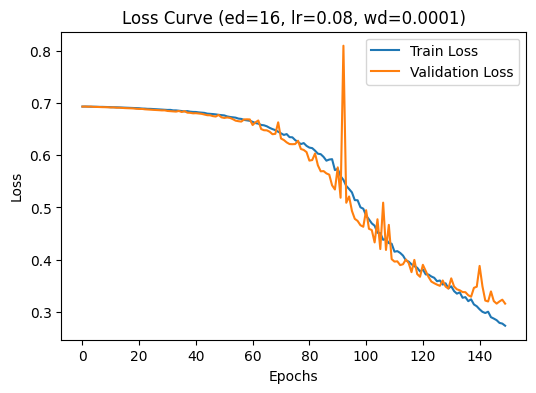

Run 1 Best Val Accuracy: 0.87375
Best model = run 1'
 Experiment 2/12: {'embedding_dim': 16, 'learning_rate': 0.08, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6935, Val Loss: 0.6931
Epoch 10, Train Loss: 0.6923, Val Loss: 0.6916
Epoch 20, Train Loss: 0.6916, Val Loss: 0.6908
Epoch 30, Train Loss: 0.6908, Val Loss: 0.6905
Epoch 40, Train Loss: 0.6907, Val Loss: 0.6897
Epoch 50, Train Loss: 0.6905, Val Loss: 0.6896
Epoch 60, Train Loss: 0.6904, Val Loss: 0.6891
Epoch 70, Train Loss: 0.6902, Val Loss: 0.6890
Epoch 80, Train Loss: 0.6901, Val Loss: 0.6890
Epoch 90, Train Loss: 0.6902, Val Loss: 0.6891
Early stopping at epoch 91 (no improvement for 15 epochs)
Best epoch: 76, Best Val Loss: 0.6890, Train Accuracy: 0.5264, Val Accuracy: 0.5350


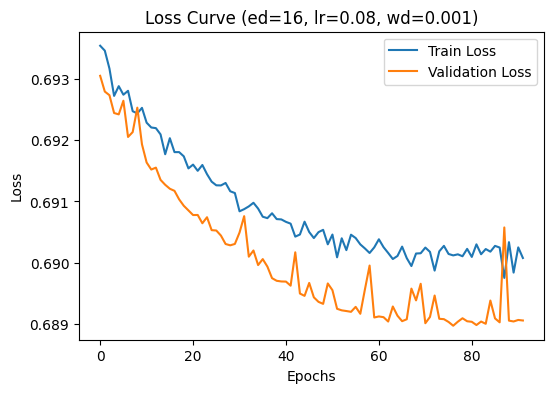

Run 2 Best Val Accuracy: 0.55125
 Experiment 3/12: {'embedding_dim': 16, 'learning_rate': 0.15, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6936, Val Loss: 0.6931
Epoch 10, Train Loss: 0.6922, Val Loss: 0.6916
Epoch 20, Train Loss: 0.6902, Val Loss: 0.6896
Epoch 30, Train Loss: 0.6858, Val Loss: 0.6859
Epoch 40, Train Loss: 0.6786, Val Loss: 0.6728
Epoch 50, Train Loss: 0.6550, Val Loss: 0.6428
Epoch 60, Train Loss: 0.5730, Val Loss: 0.5485
Epoch 70, Train Loss: 0.4654, Val Loss: 0.4397
Epoch 80, Train Loss: 0.3826, Val Loss: 0.3717
Epoch 90, Train Loss: 0.3152, Val Loss: 0.3510
Epoch 100, Train Loss: 0.2430, Val Loss: 0.3185
Epoch 110, Train Loss: 0.1763, Val Loss: 0.3231
Early stopping at epoch 118 (no improvement for 15 epochs)
Best epoch: 103, Best Val Loss: 0.3183, Train Accuracy: 0.9228, Val Accuracy: 0.8744


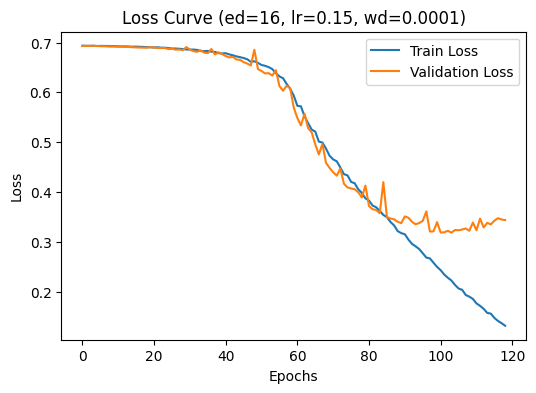

Run 3 Best Val Accuracy: 0.8775
Best model = run 3'
 Experiment 4/12: {'embedding_dim': 16, 'learning_rate': 0.15, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6936, Val Loss: 0.6931
Epoch 10, Train Loss: 0.6920, Val Loss: 0.6916
Epoch 20, Train Loss: 0.6913, Val Loss: 0.6906
Epoch 30, Train Loss: 0.6911, Val Loss: 0.6902
Epoch 40, Train Loss: 0.6912, Val Loss: 0.6902
Epoch 50, Train Loss: 0.6916, Val Loss: 0.6904
Early stopping at epoch 51 (no improvement for 15 epochs)
Best epoch: 36, Best Val Loss: 0.6901, Train Accuracy: 0.5242, Val Accuracy: 0.5344


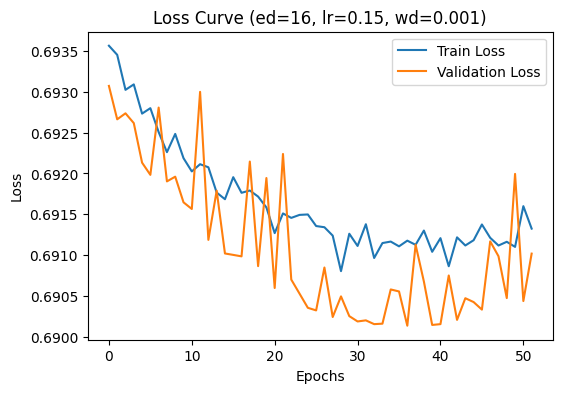

Run 4 Best Val Accuracy: 0.55
 Experiment 5/12: {'embedding_dim': 32, 'learning_rate': 0.08, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6935, Val Loss: 0.6930
Epoch 10, Train Loss: 0.6924, Val Loss: 0.6918
Epoch 20, Train Loss: 0.6912, Val Loss: 0.6901
Epoch 30, Train Loss: 0.6896, Val Loss: 0.6882
Epoch 40, Train Loss: 0.6875, Val Loss: 0.6859
Epoch 50, Train Loss: 0.6853, Val Loss: 0.6825
Epoch 60, Train Loss: 0.6806, Val Loss: 0.6804
Epoch 70, Train Loss: 0.6736, Val Loss: 0.6714
Epoch 80, Train Loss: 0.6604, Val Loss: 0.6625
Epoch 90, Train Loss: 0.6384, Val Loss: 0.6364
Epoch 100, Train Loss: 0.6087, Val Loss: 0.5960
Epoch 110, Train Loss: 0.5879, Val Loss: 0.5488
Epoch 120, Train Loss: 0.5205, Val Loss: 0.4854
Epoch 130, Train Loss: 0.4558, Val Loss: 0.4343
Epoch 140, Train Loss: 0.4038, Val Loss: 0.4418
Epoch 149, Train Loss: 0.3740, Val Loss: 0.3642
Best epoch: 149, Best Val Loss: 0.3642, Train Accuracy: 0.8483, Val Accuracy: 0.8556


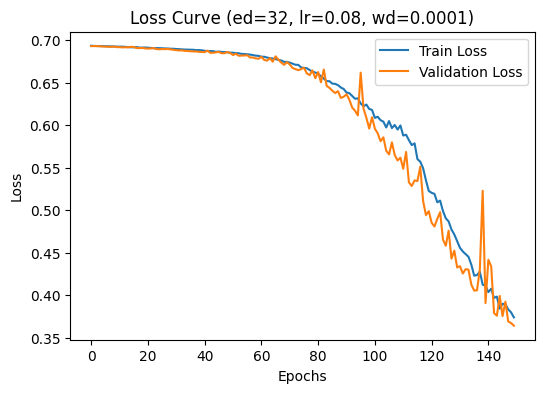

Run 5 Best Val Accuracy: 0.85625
 Experiment 6/12: {'embedding_dim': 32, 'learning_rate': 0.08, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6935, Val Loss: 0.6935
Epoch 10, Train Loss: 0.6919, Val Loss: 0.6917
Epoch 20, Train Loss: 0.6911, Val Loss: 0.6900
Epoch 30, Train Loss: 0.6899, Val Loss: 0.6906
Epoch 40, Train Loss: 0.6897, Val Loss: 0.6885
Epoch 50, Train Loss: 0.6887, Val Loss: 0.6881
Epoch 60, Train Loss: 0.6892, Val Loss: 0.6884
Epoch 70, Train Loss: 0.6891, Val Loss: 0.6877
Epoch 80, Train Loss: 0.6894, Val Loss: 0.6877
Early stopping at epoch 87 (no improvement for 15 epochs)
Best epoch: 72, Best Val Loss: 0.6876, Train Accuracy: 0.5309, Val Accuracy: 0.5400


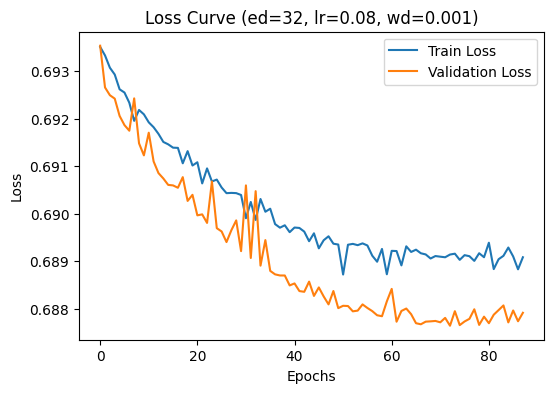

Run 6 Best Val Accuracy: 0.558125
 Experiment 7/12: {'embedding_dim': 32, 'learning_rate': 0.15, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6933, Val Loss: 0.6937
Epoch 10, Train Loss: 0.6910, Val Loss: 0.6895
Epoch 20, Train Loss: 0.6868, Val Loss: 0.6841
Epoch 30, Train Loss: 0.6801, Val Loss: 0.6749
Epoch 40, Train Loss: 0.6617, Val Loss: 0.6506
Epoch 50, Train Loss: 0.6073, Val Loss: 0.6873
Epoch 60, Train Loss: 0.5122, Val Loss: 0.4798
Epoch 70, Train Loss: 0.4314, Val Loss: 0.4066
Epoch 80, Train Loss: 0.3586, Val Loss: 0.3885
Epoch 90, Train Loss: 0.2917, Val Loss: 0.3235
Epoch 100, Train Loss: 0.2191, Val Loss: 0.3136
Epoch 110, Train Loss: 0.1561, Val Loss: 0.3247
Early stopping at epoch 115 (no improvement for 15 epochs)
Best epoch: 100, Best Val Loss: 0.3136, Train Accuracy: 0.9256, Val Accuracy: 0.8738


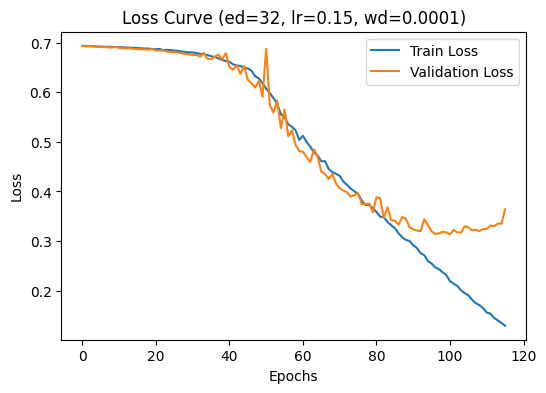

Run 7 Best Val Accuracy: 0.875
 Experiment 8/12: {'embedding_dim': 32, 'learning_rate': 0.15, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6934, Val Loss: 0.6945
Epoch 10, Train Loss: 0.6920, Val Loss: 0.6910
Epoch 20, Train Loss: 0.6912, Val Loss: 0.6899
Epoch 30, Train Loss: 0.6906, Val Loss: 0.6894
Epoch 40, Train Loss: 0.6900, Val Loss: 0.6912
Epoch 50, Train Loss: 0.6905, Val Loss: 0.6892
Early stopping at epoch 57 (no improvement for 15 epochs)
Best epoch: 42, Best Val Loss: 0.6890, Train Accuracy: 0.5294, Val Accuracy: 0.5369


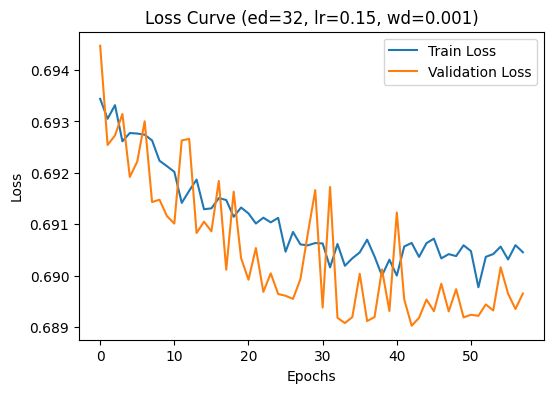

Run 8 Best Val Accuracy: 0.5525
 Experiment 9/12: {'embedding_dim': 64, 'learning_rate': 0.08, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6933, Val Loss: 0.6931
Epoch 10, Train Loss: 0.6920, Val Loss: 0.6913
Epoch 20, Train Loss: 0.6905, Val Loss: 0.6891
Epoch 30, Train Loss: 0.6882, Val Loss: 0.6862
Epoch 40, Train Loss: 0.6848, Val Loss: 0.6832
Epoch 50, Train Loss: 0.6800, Val Loss: 0.6787
Epoch 60, Train Loss: 0.6717, Val Loss: 0.6660
Epoch 70, Train Loss: 0.6565, Val Loss: 0.6650
Epoch 80, Train Loss: 0.6353, Val Loss: 0.6176
Epoch 90, Train Loss: 0.6063, Val Loss: 0.5794
Epoch 100, Train Loss: 0.5880, Val Loss: 0.7217
Epoch 110, Train Loss: 0.5381, Val Loss: 0.4957
Epoch 120, Train Loss: 0.5020, Val Loss: 0.4763
Epoch 130, Train Loss: 0.4469, Val Loss: 0.4281
Epoch 140, Train Loss: 0.4279, Val Loss: 0.4198
Epoch 149, Train Loss: 0.3962, Val Loss: 0.3693
Best epoch: 149, Best Val Loss: 0.3693, Train Accuracy: 0.8416, Val Accuracy: 0.8500


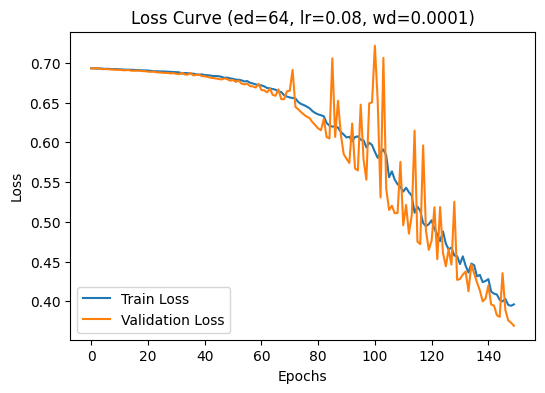

Run 9 Best Val Accuracy: 0.85
 Experiment 10/12: {'embedding_dim': 64, 'learning_rate': 0.08, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6936, Val Loss: 0.6933
Epoch 10, Train Loss: 0.6925, Val Loss: 0.6918
Epoch 20, Train Loss: 0.6915, Val Loss: 0.6910
Epoch 30, Train Loss: 0.6911, Val Loss: 0.6901
Epoch 40, Train Loss: 0.6906, Val Loss: 0.6894
Epoch 50, Train Loss: 0.6902, Val Loss: 0.6890
Epoch 60, Train Loss: 0.6901, Val Loss: 0.6889
Epoch 70, Train Loss: 0.6899, Val Loss: 0.6886
Epoch 80, Train Loss: 0.6900, Val Loss: 0.6886
Epoch 90, Train Loss: 0.6898, Val Loss: 0.6897
Early stopping at epoch 90 (no improvement for 15 epochs)
Best epoch: 75, Best Val Loss: 0.6886, Train Accuracy: 0.5286, Val Accuracy: 0.5369


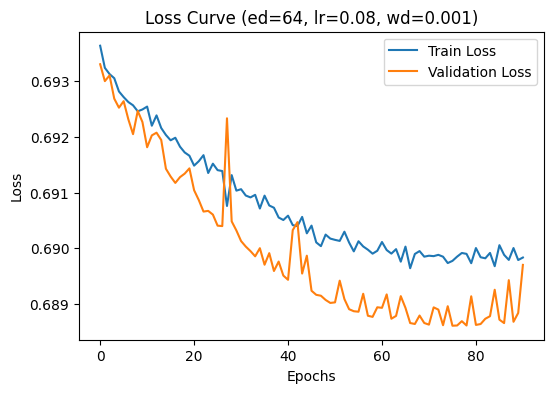

Run 10 Best Val Accuracy: 0.550625
 Experiment 11/12: {'embedding_dim': 64, 'learning_rate': 0.15, 'weight_decay': 0.0001}
Epochs: 150
Epoch 0, Train Loss: 0.6935, Val Loss: 0.6933
Epoch 10, Train Loss: 0.6903, Val Loss: 0.6903
Epoch 20, Train Loss: 0.6867, Val Loss: 0.6831
Epoch 30, Train Loss: 0.6774, Val Loss: 0.6718
Epoch 40, Train Loss: 0.6585, Val Loss: 0.6411
Epoch 50, Train Loss: 0.6367, Val Loss: 0.6057
Epoch 60, Train Loss: 0.6171, Val Loss: 0.5738
Epoch 70, Train Loss: 0.5505, Val Loss: 0.5095
Epoch 80, Train Loss: 0.4932, Val Loss: 0.4625
Epoch 90, Train Loss: 0.4364, Val Loss: 0.4232
Epoch 100, Train Loss: 0.3879, Val Loss: 0.3734
Epoch 110, Train Loss: 0.3437, Val Loss: 0.4137
Epoch 120, Train Loss: 0.3005, Val Loss: 0.3215
Epoch 130, Train Loss: 0.2473, Val Loss: 0.3083
Epoch 140, Train Loss: 0.1926, Val Loss: 0.3012
Epoch 149, Train Loss: 0.1360, Val Loss: 0.3340
Best epoch: 137, Best Val Loss: 0.2998, Train Accuracy: 0.9287, Val Accuracy: 0.8856


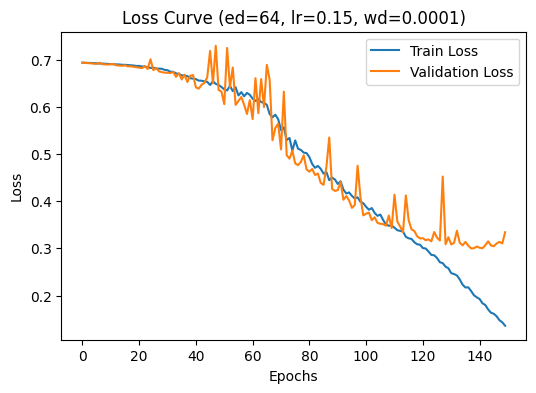

Run 11 Best Val Accuracy: 0.885625
Best model = run 11'
 Experiment 12/12: {'embedding_dim': 64, 'learning_rate': 0.15, 'weight_decay': 0.001}
Epochs: 150
Epoch 0, Train Loss: 0.6936, Val Loss: 0.6929
Epoch 10, Train Loss: 0.6922, Val Loss: 0.6917
Epoch 20, Train Loss: 0.6915, Val Loss: 0.6906
Epoch 30, Train Loss: 0.6903, Val Loss: 0.6910
Epoch 40, Train Loss: 0.6908, Val Loss: 0.6894
Epoch 50, Train Loss: 0.6907, Val Loss: 0.6898
Early stopping at epoch 55 (no improvement for 15 epochs)
Best epoch: 40, Best Val Loss: 0.6894, Train Accuracy: 0.5255, Val Accuracy: 0.5419


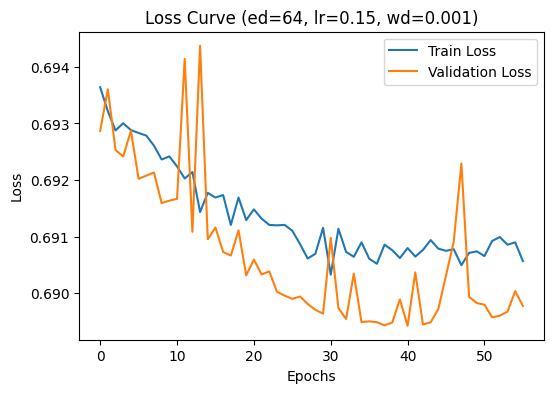

Run 12 Best Val Accuracy: 0.54875
Best Parameters: {'embedding_dim': 64, 'learning_rate': 0.15, 'weight_decay': 0.0001}
Best Val Accuracy: 0.885625


In [ ]:
import itertools
import matplotlib.pyplot as plt

''' automate the hyperparameter to search so I don't have to do it manually like last time'''

grid = {
    'embedding_dim': [16, 32, 64],
    'learning_rate': [0.08, 0.15], #smaller rates did not make meaningufl improvements
    'weight_decay': [0.001, 0.0001]
}

# generate parameter combinations
keys, values = zip(*grid.items())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_acc = 0.0
best_params = None


def plot_and_save_loss(history, filename, title):
    plt.figure(figsize=(6, 4))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# main loop
for i, params in enumerate(all_combinations):
    print(f" Experiment {i+1}/{len(all_combinations)}: {params}")
   
    
    
    model = SimpleAttentionClassifier(vocab_size=len(word2idx), embedding_dim=params['embedding_dim'], d_k=params['embedding_dim'])
    
    history = model.train(
    train_padded, train_mask, y_train,
    val_padded, val_mask, y_val,
    epochs=150,
    learning_rate=params['learning_rate'],
    weight_decay=params['weight_decay'],
    patience=15         #add early stopping to speed up training
    )
    
   # naming
    ed = params['embedding_dim']
    lr = params['learning_rate']
    wd = params['weight_decay']
    
    plot_filename = f"loss_curve_ed{ed}_lr{lr}_wd{wd}.png"
    plot_title = f"Loss Curve (ed={ed}, lr={lr}, wd={wd})"
    plot_and_save_loss(history, plot_filename, plot_title)
    
    #find the best acccuracy and save weights
    iter_best_acc = max(history['val_accuracy'])
    print(f"Run {i+1} Best Val Accuracy: {iter_best_acc}")
    
    if iter_best_acc > best_acc:
        best_acc = iter_best_acc
        best_params = params
        np.savez('best_transformer_weights.npz', **model.params)
        print(f"Best model = run {i+1}'")



print(f"Best Parameters: {best_params}")
print(f"Best Val Accuracy: {best_acc}")


Test lr=0.2 as larger learning rate seemed to show better results.

In [ ]:
model = SimpleAttentionClassifier(vocab_size=len(word2idx), embedding_dim=64, d_k=64)
    
history = model.train(
    train_padded, train_mask, y_train,
    val_padded, val_mask, y_val,
    epochs=150,
    learning_rate=0.2,
    weight_decay=0.0001,
    patience=15       
    )

Epochs: 150
Epoch 0, Train Loss: 0.6937, Val Loss: 0.6928
Epoch 10, Train Loss: 0.6910, Val Loss: 0.6898
Epoch 20, Train Loss: 0.6849, Val Loss: 0.6974
Epoch 30, Train Loss: 0.6749, Val Loss: 0.6731
Epoch 40, Train Loss: 0.6502, Val Loss: 0.6311
Epoch 50, Train Loss: 0.6241, Val Loss: 0.5816
Epoch 60, Train Loss: 0.5392, Val Loss: 0.4995
Epoch 70, Train Loss: 0.4805, Val Loss: 0.4454
Epoch 80, Train Loss: 0.4340, Val Loss: 0.4119
Epoch 90, Train Loss: 0.3681, Val Loss: 0.4199
Epoch 100, Train Loss: 0.2974, Val Loss: 0.3252
Epoch 110, Train Loss: 0.2166, Val Loss: 0.3032
Epoch 120, Train Loss: 0.1301, Val Loss: 0.3132
Early stopping at epoch 125 (no improvement for 15 epochs)
Best epoch: 110, Best Val Loss: 0.3032, Train Accuracy: 0.9259, Val Accuracy: 0.8738


## Testing

evaluate_predictions = Computes a standard binary confusion matrix (True/False Positives and Negatives) to calculate overall Accuracy, Precision, Recall, and F1-Score while handling zero-division edge cases.


In [ ]:
def evaluate_predictions(y_pred, y_true):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


# MLP Test
# reuse the same fitted vectorizer from training
x_test_tfidf = vectorizer.transform(test_texts).toarray()
y_test_mlp = np.array(test_labels).reshape(-1, 1)

mlp_test_output, _ = model.forward_pass(x_test_tfidf)
mlp_test_pred = (mlp_test_output > 0.5).astype(int)

mlp_results = evaluate_predictions(mlp_test_pred, y_test_mlp)
print("MLP Test Results:")
for k, v in mlp_results.items():
    print(f"  {k}: {v:.4f}")

MLP Test Results:
  accuracy: 0.9005
  precision: 0.9050
  recall: 0.8950
  f1: 0.8999


In [ ]:

def evaluate_predictions(y_pred, y_true):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# build test_padded / test_mask the same way as train/val  
test_tokenized = [tokens_index(tokenize(text), word2idx) for text in test_texts]
test_padded = np.array([pad_sequence(ids, maxlen) for ids in test_tokenized])
test_mask = (test_padded != 0).astype(int)
y_test_attn = np.array(test_labels).reshape(-1, 1)

attn_test_output, _ = forward_pass(
    test_padded, test_mask,
    model.params['embedding_matrix'], model.params['wq'], model.params['wk'], model.params['wv'],
    model.d_k, model.params['w_out'], model.params['b_out']
)
attn_test_pred = (attn_test_output > 0.5).astype(int)

attn_results = evaluate_predictions(attn_test_pred, y_test_attn)
print("Attention Test Results:")
for k, v in attn_results.items():
    print(f"  {k}: {v:.4f}")

Attention Test Results:
  accuracy: 0.8895
  precision: 0.8845
  recall: 0.8960
  f1: 0.8902
